<a href="https://colab.research.google.com/github/Alireza-hakimi/Explainable-AI-model-implementation/blob/main/model2_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, ConfusionMatrixDisplay
)
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
df = pd.read_csv("creditcard_2023.csv")

print("=" * 50)
print(f"Dataset Shape     : {df.shape}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
print("\nClass Distribution:")
print(df["Class"].value_counts())
print(f"\nFraud Rate        : {df['Class'].mean() * 100:.2f}%")
print("=" * 50)
df.head()

Dataset Shape     : (568630, 31)
Missing Values    : 0
Duplicate Rows    : 0

Class Distribution:
Class
0    284315
1    284315
Name: count, dtype: int64

Fraud Rate        : 50.00%


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


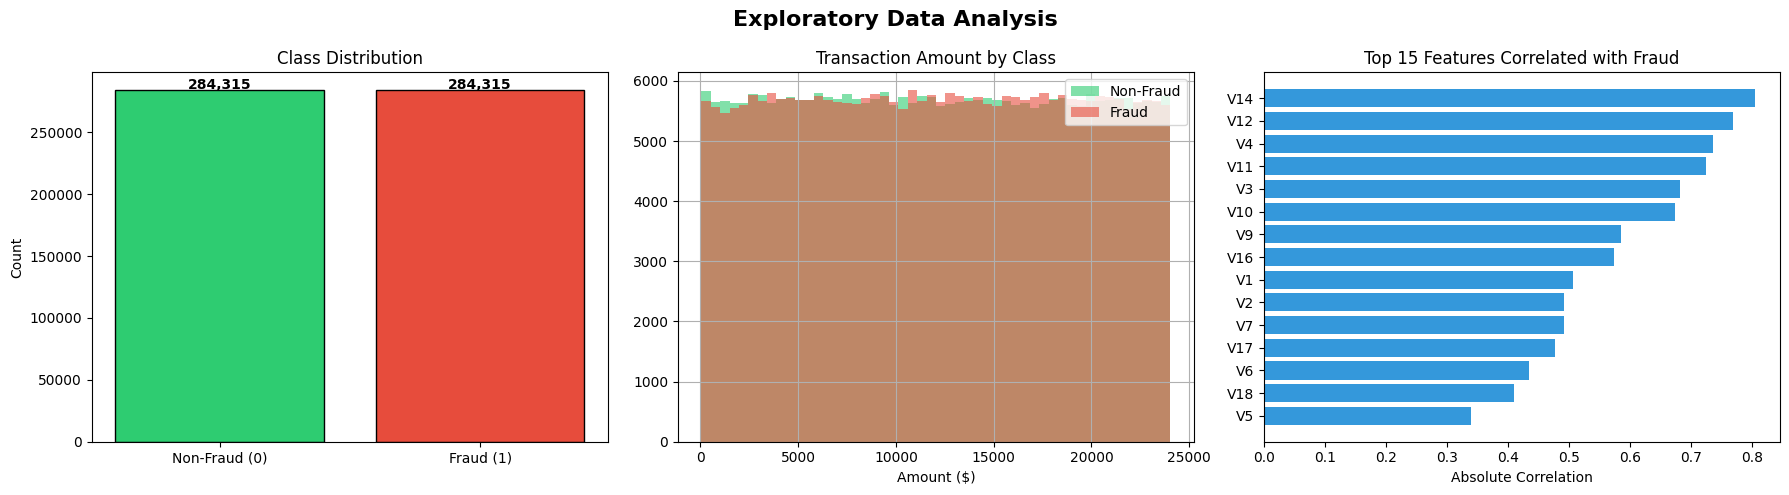

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis", fontsize=16, fontweight="bold")

# Class distribution
axes[0].bar(["Non-Fraud (0)", "Fraud (1)"],
            df["Class"].value_counts().values,
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(df["Class"].value_counts().values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

# Amount distribution by class
df[df["Class"] == 0]["Amount"].hist(ax=axes[1], bins=50, alpha=0.6,
                                    color="#2ecc71", label="Non-Fraud")
df[df["Class"] == 1]["Amount"].hist(ax=axes[1], bins=50, alpha=0.6,
                                    color="#e74c3c", label="Fraud")
axes[1].set_title("Transaction Amount by Class")
axes[1].set_xlabel("Amount ($)")
axes[1].legend()

# Top correlated features with Class
corr = df.drop("id", axis=1).corr()["Class"].drop("Class").abs().sort_values(ascending=False)
top_features = corr.head(15)
axes[2].barh(top_features.index[::-1], top_features.values[::-1], color="#3498db")
axes[2].set_title("Top 15 Features Correlated with Fraud")
axes[2].set_xlabel("Absolute Correlation")

plt.tight_layout()
plt.show()

In [ ]:
df = df.drop("id", axis=1)

X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()
X["Amount"] = scaler.fit_transform(X[["Amount"]])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size      : {X_train.shape[0]:,}")
print(f"Validation size : {X_val.shape[0]:,}")
print(f"Test size       : {X_test.shape[0]:,}")

Train size      : 398,041
Validation size : 85,294
Test size       : 85,295


In [ ]:
model = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    eval_metric           = "auc",
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")
print("Model training complete!")

[0]	validation_0-auc:0.97670
[50]	validation_0-auc:0.99891
[100]	validation_0-auc:0.99965
[150]	validation_0-auc:0.99989
[200]	validation_0-auc:0.99995
[250]	validation_0-auc:0.99997
[300]	validation_0-auc:0.99998
[350]	validation_0-auc:0.99999
[400]	validation_0-auc:0.99999
[450]	validation_0-auc:1.00000
[499]	validation_0-auc:1.00000

Best iteration: 499
Model training complete!


In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
f1  = f1_score(y_test, y_pred)

print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(f"AUC-ROC Score : {auc:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))

TEST SET RESULTS
AUC-ROC Score : 1.0000
F1 Score      : 0.9997

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     42648
       Fraud       1.00      1.00      1.00     42647

    accuracy                           1.00     85295
   macro avg       1.00      1.00      1.00     85295
weighted avg       1.00      1.00      1.00     85295



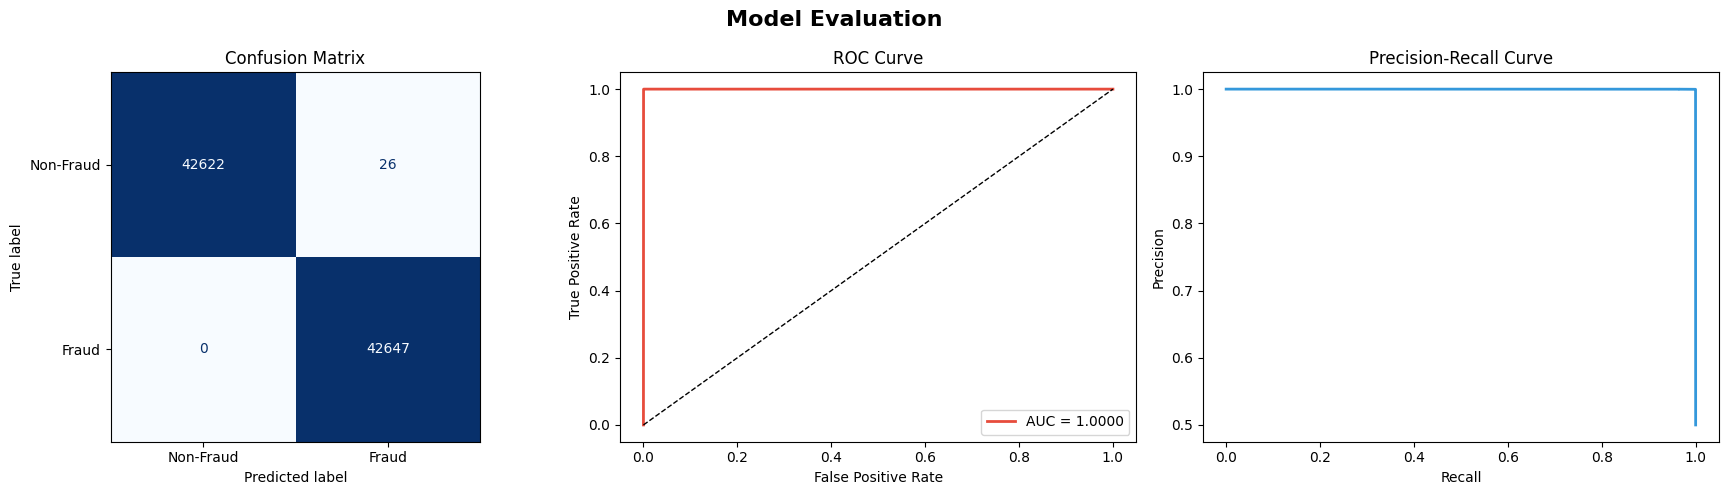

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation", fontsize=16, fontweight="bold")

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Non-Fraud", "Fraud"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color="#3498db", lw=2)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [ ]:
model.save_model("xgboost_fraud_model.json")
print("Model saved as: xgboost_fraud_model.json")

Model saved as: xgboost_fraud_model.json


In [ ]:
import shap
import numpy as np

explainer        = shap.TreeExplainer(model)
shap_values_full = explainer.shap_values(X_test, check_additivity=False)
np.save("shap_values_full.npy", shap_values_full)
print(f"SHAP values shape : {shap_values_full.shape}")
print(f"Test set shape    : {X_test.shape}")
print("Full SHAP analysis complete!")

SHAP values shape : (85295, 29)
Test set shape    : (85295, 29)
Full SHAP analysis complete!


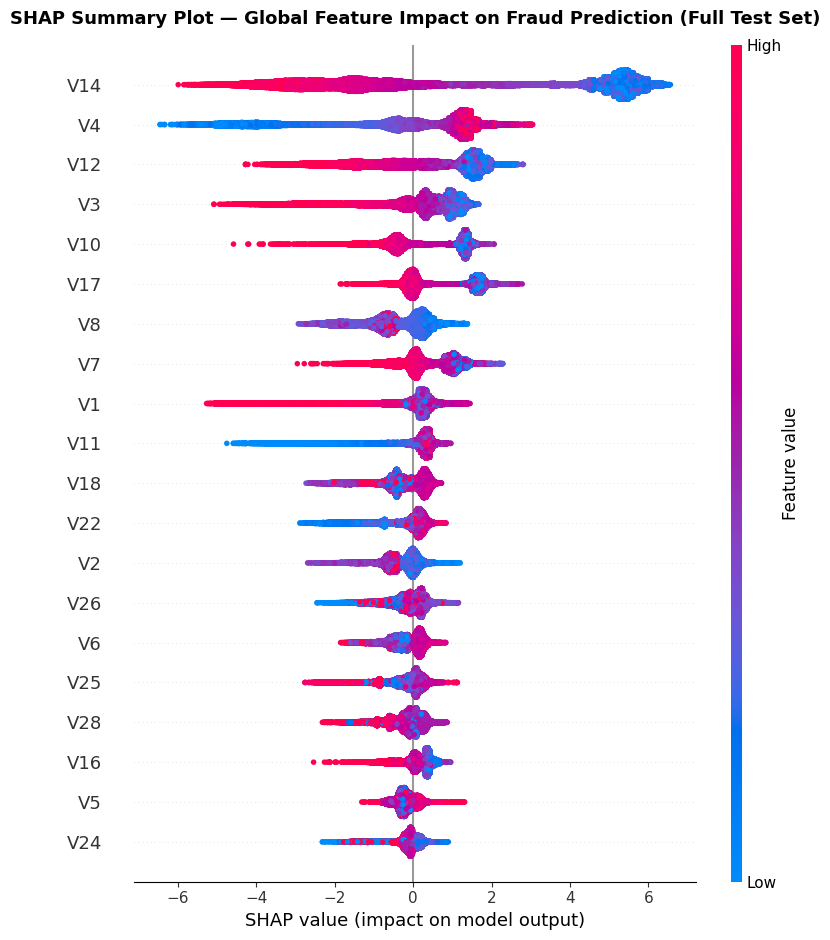

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_full, X_test, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary Plot — Global Feature Impact on Fraud Prediction (Full Test Set)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

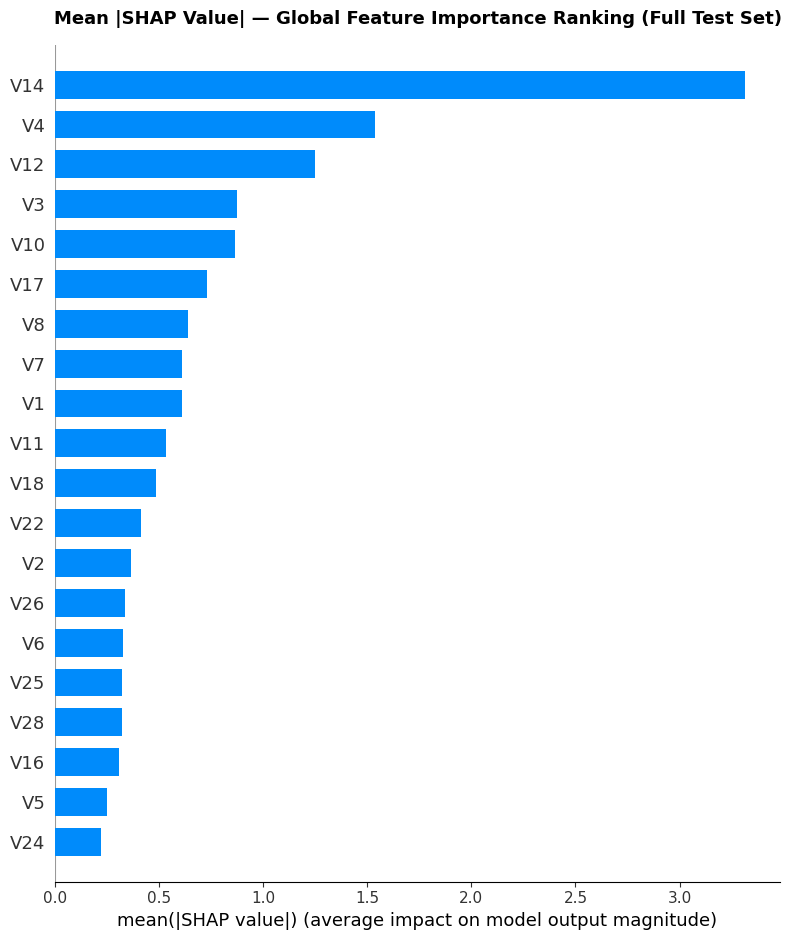

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_full, X_test, plot_type="bar", max_display=20, show=False)
plt.title("Mean |SHAP Value| — Global Feature Importance Ranking (Full Test Set)", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

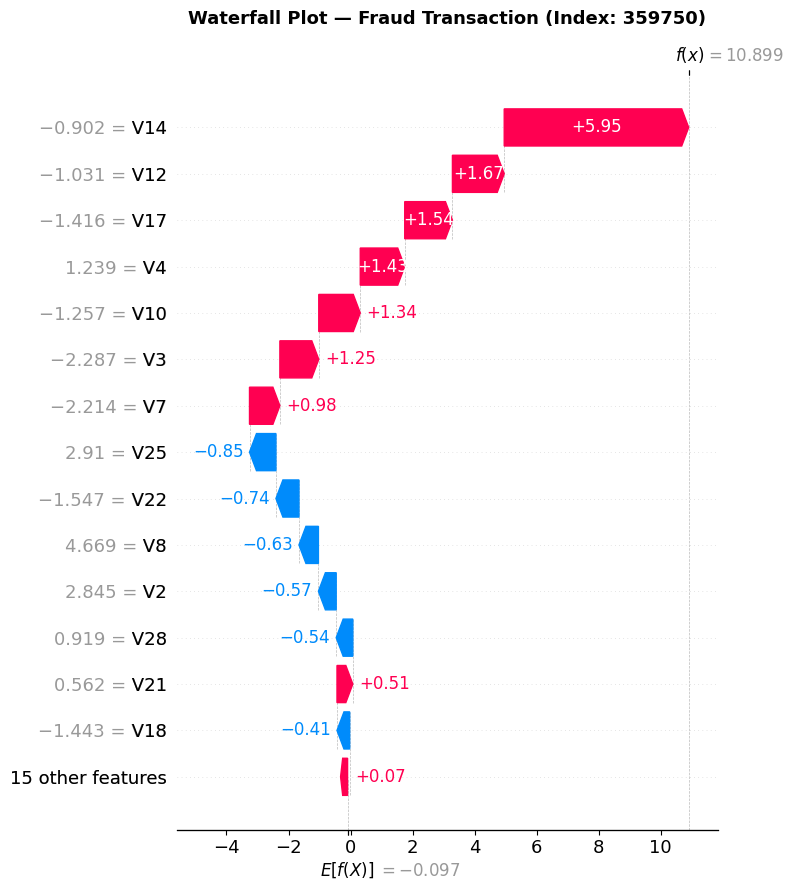

Transaction Index : 359750
True Label        : FRAUD
Fraud Probability : 1.0000


In [ ]:
fraud_indices = y_test[y_test == 1].index
sample_idx    = fraud_indices[0]
position      = X_test.index.get_loc(sample_idx)

shap.plots.waterfall(shap.Explanation(values=shap_values_full[position], base_values=explainer.expected_value, data=X_test.iloc[position], feature_names=X_test.columns.tolist()), max_display=15, show=False)
plt.title(f"Waterfall Plot — Fraud Transaction (Index: {sample_idx})", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print(f"Transaction Index : {sample_idx}")
print(f"True Label        : FRAUD")
print(f"Fraud Probability : {model.predict_proba(X_test.iloc[[position]])[0][1]:.4f}")

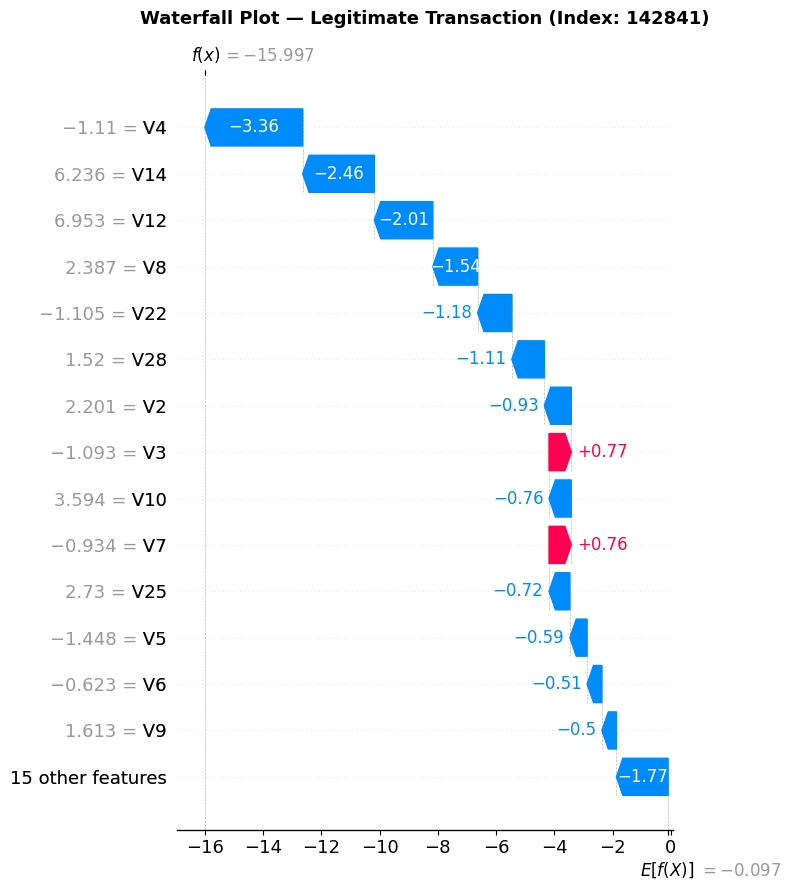

Transaction Index : 142841
True Label        : NON-FRAUD
Fraud Probability : 0.0000


In [ ]:
legit_indices = y_test[y_test == 0].index
sample_idx2   = legit_indices[0]
position2     = X_test.index.get_loc(sample_idx2)

shap.plots.waterfall(shap.Explanation(values=shap_values_full[position2], base_values=explainer.expected_value, data=X_test.iloc[position2], feature_names=X_test.columns.tolist()), max_display=15, show=False)
plt.title(f"Waterfall Plot — Legitimate Transaction (Index: {sample_idx2})", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print(f"Transaction Index : {sample_idx2}")
print(f"True Label        : NON-FRAUD")
print(f"Fraud Probability : {model.predict_proba(X_test.iloc[[position2]])[0][1]:.4f}")

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_full[position], X_test.iloc[position], feature_names=X_test.columns.tolist())

## Conclusion

This study applied a **SHAP-based Explainable AI (XAI)** framework to a trained XGBoost fraud detection model, with the core objective of understanding why the model makes its predictions rather than simply what it predicts. The analysis was conducted across two levels, global interpretability and local transaction auditing each revealing distinct and meaningful insights into the model's decision-making behavior.


### What the XAI Analysis Concluded

At the global level, the SHAP Beeswarm and Bar Chart analyses confirmed that the model's fraud detection logic is driven by a clear feature hierarchy. **V14 is the single most influential feature**, carrying more predictive weight than any other variable by a significant margin, followed by V4, V12, and V3 as strong supporting signals. Crucially, the Beeswarm plot revealed that these features do not operate as static rules their direction of influence flips depending on the transaction context, demonstrating that the model has internalized genuinely complex, non-linear fraud patterns rather than simple thresholds.

At the local level, the Waterfall and Force plots validated this behavior on individual transactions. The fraud case and the legitimate case showed the exact same top features contributing in completely opposite directions, confirming that the model evaluates each transaction on its own terms. This level of contextual sensitivity is what separates a robust fraud detection system from a brittle rule-based one, and the XAI framework made this behavior directly visible and verifiable.

